Research Question: 

How are three-point shooting, rebounding, assists, and turnovers associated with an NBA team's regular-season win percentage? This project will measure whether common team performance statistics are associated with success during the NBA regular season. The analysis focuses on four potential predictors-three-point shooting percentage, rebounds, assists and turnovers-and their relationship with regular-season win percentage.

Dataset: 

The dataset was obtained from Kaggle using the Kaggle API, which provides programmatic access to publicly available datasets. Kaggle documents the use of its API for downloading datasets programmatically. The dataset contains NBA team statistics covering the 2000-01 through 2023-24 regular seasons. The project's CSV file contains 716 observations and 29 variables. The unit of analysis is an NBA team-season, meaning that each row represents one NBA team's performance during one regular season. The dataset includes variables for wins, losses, win percentage, shooting percentages, rebounds, assists, turnovers, steals, blocks, plus/minus, and other team statistics. The dependent variable is win_percentage. The primary predictor variables are three_point_percentage, rebounds, assists, and turnovers. The dataset contains no missing values across its 29 variables. 


In [1]:
!pip install -q kaggle

In [4]:
!kaggle datasets list -s "NBA Team Stats"

ref                                                           title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
daverosenman/nba-finals-team-stats                            NBA Finals Team Stats                                    12225  2018-08-09 20:21:26.403000           6784         80  0.7058824        
mharvnek/nba-team-stats-00-to-18                              NBA Team Stats                                           57126  2024-04-16 22:02:56.500000           2976         32  0.8235294        
vivovinco/nba-player-stats                                    2021-2022 NBA Player Stats                               49461  2022-06-18 07:52:52.723000          13626        161  1                
justinas/n

In [5]:
# Data Acquisition
!kaggle datasets download -d mharvnek/nba-team-stats-00-to-18 --unzip

Dataset URL: https://www.kaggle.com/datasets/mharvnek/nba-team-stats-00-to-18
License(s): CC0-1.0
100%|██████████████████████████████████████| 55.8k/55.8k [00:00<00:00, 59.9MB/s]



In [7]:
import pandas as pd

df = pd.read_csv("nba_team_stats_00_to_23.csv")

df.head()

,teamstatspk,Team,games_played,wins,losses,win_percentage,Min,points,field_goals_made,field_goals_attempted,...,rebounds,assists,turnovers,steals,blocks,blocks_attempted,personal_fouls,personal_fouls_drawn,plus_minus,season
0,0,Boston Celtics,82,64,18,0.780,3966,9887,3601,7396,...,3799,2207,979,557,538,304,1326,1416,930,2023-24
1,1,Denver Nuggets,82,57,25,0.695,3941,9418,3610,7279,...,3643,2415,1036,585,456,394,1489,1467,431,2023-24
2,2,Oklahoma City Thunder,82,57,25,0.695,3961,9847,3653,7324,...,3447,2223,1039,694,538,419,1545,1548,608,2023-24
3,3,Minnesota Timberwolves,82,56,26,0.683,3961,9264,3383,6974,...,3577,2184,1162,647,497,371,1544,1630,529,2023-24
4,4,LA Clippers,82,51,31,0.622,3941,9481,3473,7108,...,3523,2097,1078,640,413,384,1519,1537,269,2023-24


In [8]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (716, 29)

Missing values:
teamstatspk                 0
Team                        0
games_played                0
wins                        0
losses                      0
win_percentage              0
Min                         0
points                      0
field_goals_made            0
field_goals_attempted       0
field_goal_percentage       0
three_pointers_made         0
three_pointers_attempted    0
three_point_percentage      0
free_throws_made            0
free_throw_attempted        0
free_throw_percentage       0
offensive_rebounds          0
defensive_rebounds          0
rebounds                    0
assists                     0
turnovers                   0
steals                      0
blocks                      0
blocks_attempted            0
personal_fouls              0
personal_fouls_drawn        0
plus_minus                  0
season                      0
dtype: int64


| Variable               | Role                  | Conceptualization | Operationalization |
| -----------------      | -----------------     | ----------------- | -----------------  |
| Win Percentage         | Outcome               | A team's regular-season success | wins / games_played, represented by win_percentage
| Three-Point Percentage | Predictor             | A team's efficiency when shooting three-point field goals | three_point_percentage, the percentage of 3-point attempts made |
| Rebounds               | Predictor             | A team's ability to recover missed shots and gain/retain possession | rebounds, total offensive + defensive rebounds  |
| Assists                | Predictor             | A team's passing and offensive collaboration |assists, total assists recorded by the team |
| Turnovers              | Predictor             | How frequently a team loses possession while on offense | turnovers, total turnovers committed by the team |
| Season                 | Context/Time variable | The NBA regular season in which the team statistics were recorded | season, such as 2023-24 |



This project examines whether selected team-level performance statistics are associated with regular-season success in the NBA. Specifically, the analysis focuses on three-point shooting efficiency, rebounding, assists, and turnovers as potential predictors of team win percentage. These variables represent different aspects of team performance, including shooting efficiency, possession recovery, offensive teamwork, and ball security. The unit of analysis is an NBA team-season, so each observation represents one team's performance during one regular season. 

In [15]:
# Data Cleaning and Preparation

# Inspect the data types of each variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 716 entries, 0 to 715
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   teamstatspk               716 non-null    int64  
 1   Team                      716 non-null    object 
 2   games_played              716 non-null    int64  
 3   wins                      716 non-null    int64  
 4   losses                    716 non-null    int64  
 5   win_percentage            716 non-null    float64
 6   Min                       716 non-null    int64  
 7   points                    716 non-null    int64  
 8   field_goals_made          716 non-null    int64  
 9   field_goals_attempted     716 non-null    int64  
 10  field_goal_percentage     716 non-null    float64
 11  three_pointers_made       716 non-null    int64  
 12  three_pointers_attempted  716 non-null    int64  
 13  three_point_percentage    716 non-null    float64
 14  free_throw

In [10]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
# Check the unique values and data types of key variables
print(df[["win_percentage",
          "three_point_percentage",
          "rebounds",
          "assists",
          "turnovers",
          "season"]].dtypes)

win_percentage            float64
three_point_percentage    float64
rebounds                    int64
assists                     int64
turnovers                   int64
season                     object
dtype: object


In [12]:
# Select variables needed for the analysis
analysis_df = df[[
    "win_percentage",
    "three_point_percentage",
    "rebounds",
    "assists",
    "turnovers",
    "season"
]].copy()

analysis_df.head()

,win_percentage,three_point_percentage,rebounds,assists,turnovers,season
0,0.780,38.8,3799,2207,979,2023-24
1,0.695,37.4,3643,2415,1036,2023-24
2,0.695,38.9,3447,2223,1039,2023-24
3,0.683,38.7,3577,2184,1162,2023-24
4,0.622,38.1,3523,2097,1078,2023-24


In [13]:
print("Analysis dataset shape:", analysis_df.shape)

Analysis dataset shape: (716, 6)


In [14]:
# Check the ranges of the numerical variables
analysis_df.describe()

,win_percentage,three_point_percentage,rebounds,assists,turnovers
count,716.000000,716.000000,716.000000,716.000000,716.000000
mean,0.499784,35.588408,3439.062849,1812.224860,1155.023743
std,0.148919,1.894185,232.258935,209.520421,111.140487
min,0.106000,27.800000,2560.000000,1224.000000,738.000000
25%,0.390000,34.400000,3325.000000,1680.000000,1086.000000
50%,0.512000,35.500000,3459.500000,1795.500000,1157.000000
75%,0.610000,36.900000,3585.250000,1933.500000,1224.000000
max,0.890000,41.600000,4078.000000,2522.000000,1514.000000


Data Cleaning and Preparation: The dataset was inspected for missing values, duplicate observations, and inappropiate data types. No missing values or duplicate rows were found. The variables used in the analysis were already stored in appropriate numeric formats, so no type conversions were necessary. To prepare the dataset for analysis, a seperate dataframe was created containing only the variables directly relevant to the research question. This reduced the dataset from 29 variables to 6 variables while retaining all 716 team-season observations. This approach keeps the analysis focused on the variables needed to examine the relationship between team performance statistics and win percentage without unnecessarily modifying the original dataset. 

Range and Outlier Check: Descriptive statistics were reviewed to identify potentially invalid or unusual values in the analysis variables. The observed ranges were plausible for NBA team-season statistics, and no clearly invalid values were identified. Therefore, no observations were removed or modified based on their numerical ranges. Retaining the full dataset avoids unnecessarily excluding legitimate team performances that may represent unusually strong or weak seasons. 

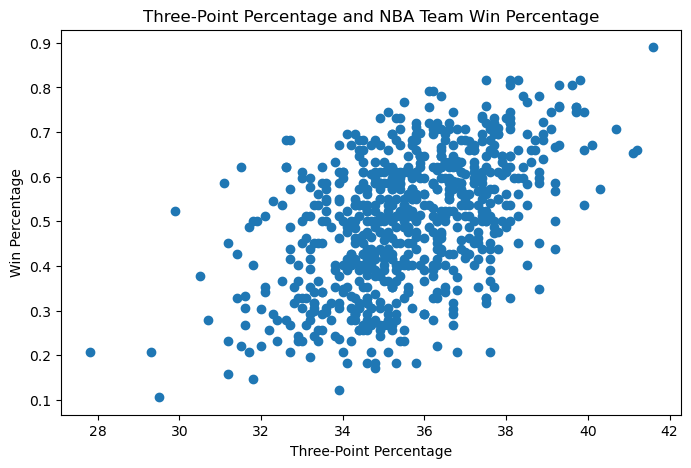

In [16]:
## Visualizations

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    analysis_df["three_point_percentage"],
    analysis_df["win_percentage"]
)

plt.title("Three-Point Percentage and NBA Team Win Percentage")
plt.xlabel("Three-Point Percentage")
plt.ylabel("Win Percentage")

plt.show()

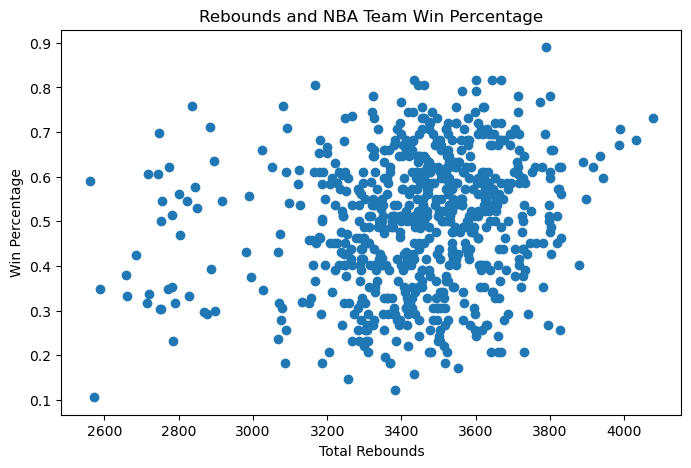

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    analysis_df["rebounds"],
    analysis_df["win_percentage"]
)

plt.title("Rebounds and NBA Team Win Percentage")
plt.xlabel("Total Rebounds")
plt.ylabel("Win Percentage")

plt.show()

Visualization 1: Three-Point Percentage and NBA Team Win Percentage

The scatter plot shows a positive association between three-point percentage and win percentage. In general, teams with higher three-point shooting percentages tend to have higher win percentages. However, the points are spread out, indicating that three-point shooting percentage alone does not fully explain differences in team success.

Visualization 2: Rebounds and NBA Team Win Percentage

The scatter plot shows a generally positive association between total rebounds and win percentage. Teams with higher total rebounds tend to have somewhat higher win percentages, but the relationship has considerable variation. This suggests that rebounding may be associated with team success, while other factors also contribute to differences in win percentage. 

Ethics and Limitations 

Ethical Considerations

This project uses aggregated NBA team-season statistics rather than personal or sensitive information about individual people. The analysis therefore presents relatively low privacy risk because the data describe team performance rather than individual players. The dataset was obtained from Kaggle and was originally sourced from NBA.com. The analysis uses the data for educational purposes and does not attempt to identify or make claims about individual players. 

Dataset Limitations 

There are several limitations to this dataset and analysis. First, the dataset contains team-level statistics, so it cannot explain individual player performance or differences in player roles. Second, the analysis focuses on a limited set of performance variables: three point percentage, rebounds, assists, and turnovers. Other factors that may be related to winning, such as defensive performance, free-throw shooting, player availability, strength of schedule, and coaching, are not included in the analysis. 

The data also cover multiple NBA season, during which the style of play and league environment may have changed. Changes in three-point usage, offensive strategies, rules, and team composition could affect the relationships observed in the data. Although season is included as a context/time variable, the analysis does not fully account for all differences between NBA eras. 

Potential Biases 

The dataset contains observational team statistics, so the analysis can identify associations but cannot establish that a particular statistic causes a team to win more games. There may also be omitted-variable bias because important factors related to team success are not included in the model. In addition, some team statistics may be related to one another, making it difficult to isolate the independent association of each statistic with win percentage. 

Unanswered Questions

This analysis does not determine which factor is most important for winning or whether improving a particular statistic would directly cause a team to win more games. Future research could include additional variables such as defensive statistics, free-throw performance, strength of schedule, injuries, player-level statistics, or payroll. Future analysis could also examine whether these relationships have changed across different NBA eras. 


Code and Notebook 

The code used for data acquisition, data cleaning, preparation, and visualization is contained the Jupyter Notebook submitted with this project. The notebook documents the steps used to obtain the dataset through the Kaggle API, inspect and clean the data, select variables for analysis, and create the visualizations. 

Citations 

National Basketball Association. (n.d.). *NBA stats glossary*. NBA.com. https://www.nba.com/stats/help/glossary

Kaggle. (n.d.). *NBA Team Stats*. https://www.kaggle.com/datasets/mharvnek/nba-team-stats-00-to-18/data
